# LSTM testing - online and offline framework
### Anaerobic digestion of Olive Mill Waste - Crete Case Study

---

## results from LSTM retrain

the LSTM retrained model (LSTMModel(5, 30, 2, 3)) produced the best training
metrics of any model

**final training loss: 0.0001144**

this represents a 4% improvement over the LSTM first run (0.0001193), a 17%
improvement over the RNN first run (0.0001380) and a 92% improvement over the
ANN retrained model (0.001549). the model converged with a last 50 epoch
drop of 0.00000285

**R squared values (retrained LSTM):**

| output | ANN | RNN | LSTM Retrain |
|--------|-----|-----|-------------|
| dS/dt | 0.9982 | 0.9993 | 0.9995 |
| dM/dt | 0.9984 | 0.9993 | 0.9995 |
| dpH/dt | 0.9989 | 0.9977 | 0.9980 |

**residual means (standardised units):**

| output | RNN | LSTM retrain |
|--------|-----|-------------|
| dS/dt | 0.000992 | 0.000186 |
| dM/dt | 0.000012 | 0.000860 |
| dpH/dt | 0.001881 | 0.000349 |

the LSTM residual means are the smallest of any sequence model and show no
meaningful bias in any direction

**open question:**

training metrics seem misleading about offline performance.
the RNN achieved a training loss of 0.000138 and R² above 0.999 but produced
offline MAPE of 24% for volatile solids and 17% for methane due to error
accumulation in the predicted sequence window

the LSTM gating mechanism theoretically reduces this problem. the forget gate
allows the LSTM to selectively discard "corrupted"states from the sequence
history rather than carrying all previous states forward (as the RNN does)
whether this theoretical advantage leads to improvements in offline
MAPE is what this notebook determines:

**ANN offline results for reference:**

| variable | ANN online | ANN offline |
|----------|-----------|------------|
| S | 0.07% | 0.45% |
| M | 0.06% | 0.29% |
| pH | 0.00% | 0.02% |

**RNN offline results for reference:**

| variable | RNN online | RNN offline |
|----------|-----------|------------|
| S | 0.56% | 24.02% |
| M | 2.76% | 17.19% |
| pH | 0.06% | 1.02% |

---

## purpose of this notebook

the LSTM retrained model is tested on the same 4 simulation runs
used for ANN and RNN testing, using the same online and offline frameworks
so results are directly comparable across all three models


## 1. Imports

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.preprocessing import StandardScaler
from scipy.integrate import odeint

print("torch version:", torch.__version__)

torch version: 2.11.0


## 2. Load Trained Model

In [2]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim  = layer_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim,
                            batch_first=True)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0  = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim)
        c0  = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim)
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

seq_len    = 12
hidden_dim = 30
layer_dim  = 2

model = LSTMModel(5, hidden_dim, layer_dim, 3)
model.load_state_dict(torch.load('LSTM_olive_mill_retrained.pt'))
model.eval()

print(f"model loaded: LSTMModel(5, {hidden_dim}, {layer_dim}, 3)")
print(f"parameters  : {sum(p.numel() for p in model.parameters())}")
print(f"seq_len     : {seq_len}")
print("mode        : eval")

model loaded: LSTMModel(5, 30, 2, 3)
parameters  : 11973
seq_len     : 12
mode        : eval


## 3. Reconstruct Scaler

In [3]:
scaler_mean  = np.load('scaler_mean.npy')
scaler_scale = np.load('scaler_scale.npy')

scaler = StandardScaler()
scaler.mean_  = scaler_mean
scaler.scale_ = scaler_scale
scaler.var_   = scaler_scale ** 2
scaler.n_features_in_ = 8

print("scaler reconstructed")

scaler reconstructed


## 4. Generate Test Data

In [4]:
k_h   = 0.08
Y_CH4 = 380.0
k_pH  = 0.003
S_ref = 2.0
pH_eq = 6.8

def f_T(T):   return np.exp(-0.07 * (T - 35.0))
def f_pH(pH): return 1.0 / (1.0 + np.exp(-2.0 * (pH - 6.5)))

def digester_ode(state, t, T, OLR):
    S, M, pH = state
    S   = max(S, 0.0)
    pH  = max(pH, pH_eq)
    r   = k_h * S * f_T(T) * f_pH(pH)
    return [-r, Y_CH4 * r, -k_pH * max(S - S_ref, 0.0) * (pH - pH_eq)]

t_span = np.linspace(0, 30, 31)

test_conditions = [
    (30.0, 15.0, 1.0, "T=30  S0=15  OLR=1  (low temp, low substrate)"),
    (35.0, 35.0, 3.0, "T=35  S0=35  OLR=3  (optimal conditions)"),
    (42.0, 55.0, 6.0, "T=42  S0=55  OLR=6  (high temp, high substrate)"),
    (30.0, 55.0, 6.0, "T=30  S0=55  OLR=6  (low temp, high substrate)"),
]

test_data = []
for T, S0, OLR, label in test_conditions:
    sol = odeint(digester_ode, [S0, 0.0, 7.4], t_span, args=(T, OLR))
    test_data.append({'T': T, 'S0': S0, 'OLR': OLR, 'label': label, 'trajectory': sol})
    print(f"generated: {label}")

generated: T=30  S0=15  OLR=1  (low temp, low substrate)
generated: T=35  S0=35  OLR=3  (optimal conditions)
generated: T=42  S0=55  OLR=6  (high temp, high substrate)
generated: T=30  S0=55  OLR=6  (low temp, high substrate)


## 5. MAPE Function

In [5]:
def MAPE(actual, predicted):
    mask = np.abs(actual) > 1e-6
    if mask.sum() == 0:
        return np.nan
    return np.abs((actual[mask] - predicted[mask]) / actual[mask]).mean() * 100

## 6. Online Framework

In [6]:
online_results = []

for run in test_data:
    T   = run['T']
    OLR = run['OLR']
    sol = run['trajectory']

    predicted_traj = [sol[0].copy()]

    for i in range(30):
        window_start = max(0, i - seq_len + 1)
        window = sol[window_start : i + 1]

        if len(window) < seq_len:
            pad    = np.tile(sol[0], (seq_len - len(window), 1))
            window = np.vstack([pad, window])

        seq_raw = np.zeros((seq_len, 8))
        seq_raw[:, 0:3] = window
        seq_raw[:, 3]   = T
        seq_raw[:, 4]   = OLR
        seq_std = scaler.transform(seq_raw)[:, 0:5]

        x_t = torch.tensor(seq_std, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            rates_std = model(x_t).numpy()[0]

        full_std = np.zeros(8)
        full_std[0:5] = seq_std[-1]
        full_std[5:8] = rates_std
        full_phys = scaler.inverse_transform(full_std.reshape(1, -1))[0]
        dS, dM, dpH = full_phys[5], full_phys[6], full_phys[7]
        dpH = min(dpH, 0.0)

        S_next  = max(sol[i, 0] + dS,  0.0)
        M_next  = max(sol[i, 1] + dM,  0.0)
        pH_next = max(sol[i, 2] + dpH, pH_eq)

        predicted_traj.append(np.array([S_next, M_next, pH_next]))

    predicted_traj = np.array(predicted_traj)

    mape_S  = MAPE(sol[1:, 0], predicted_traj[1:, 0])
    mape_M  = MAPE(sol[1:, 1], predicted_traj[1:, 1])
    mape_pH = MAPE(sol[1:, 2], predicted_traj[1:, 2])

    online_results.append({
        'label': run['label'], 'actual': sol, 'predicted': predicted_traj,
        'mape_S': mape_S, 'mape_M': mape_M, 'mape_pH': mape_pH,
    })

    print(f"{run['label']}")
    print(f"  MAPE S:   {mape_S:.2f}%")
    print(f"  MAPE M:   {mape_M:.2f}%")
    print(f"  MAPE pH:  {mape_pH:.2f}%")
    print()

T=30  S0=15  OLR=1  (low temp, low substrate)
  MAPE S:   0.63%
  MAPE M:   2.57%
  MAPE pH:  0.01%

T=35  S0=35  OLR=3  (optimal conditions)
  MAPE S:   0.94%
  MAPE M:   4.83%
  MAPE pH:  0.08%

T=42  S0=55  OLR=6  (high temp, high substrate)
  MAPE S:   0.67%
  MAPE M:   5.67%
  MAPE pH:  0.12%

T=30  S0=55  OLR=6  (low temp, high substrate)
  MAPE S:   2.01%
  MAPE M:   6.48%
  MAPE pH:  0.13%



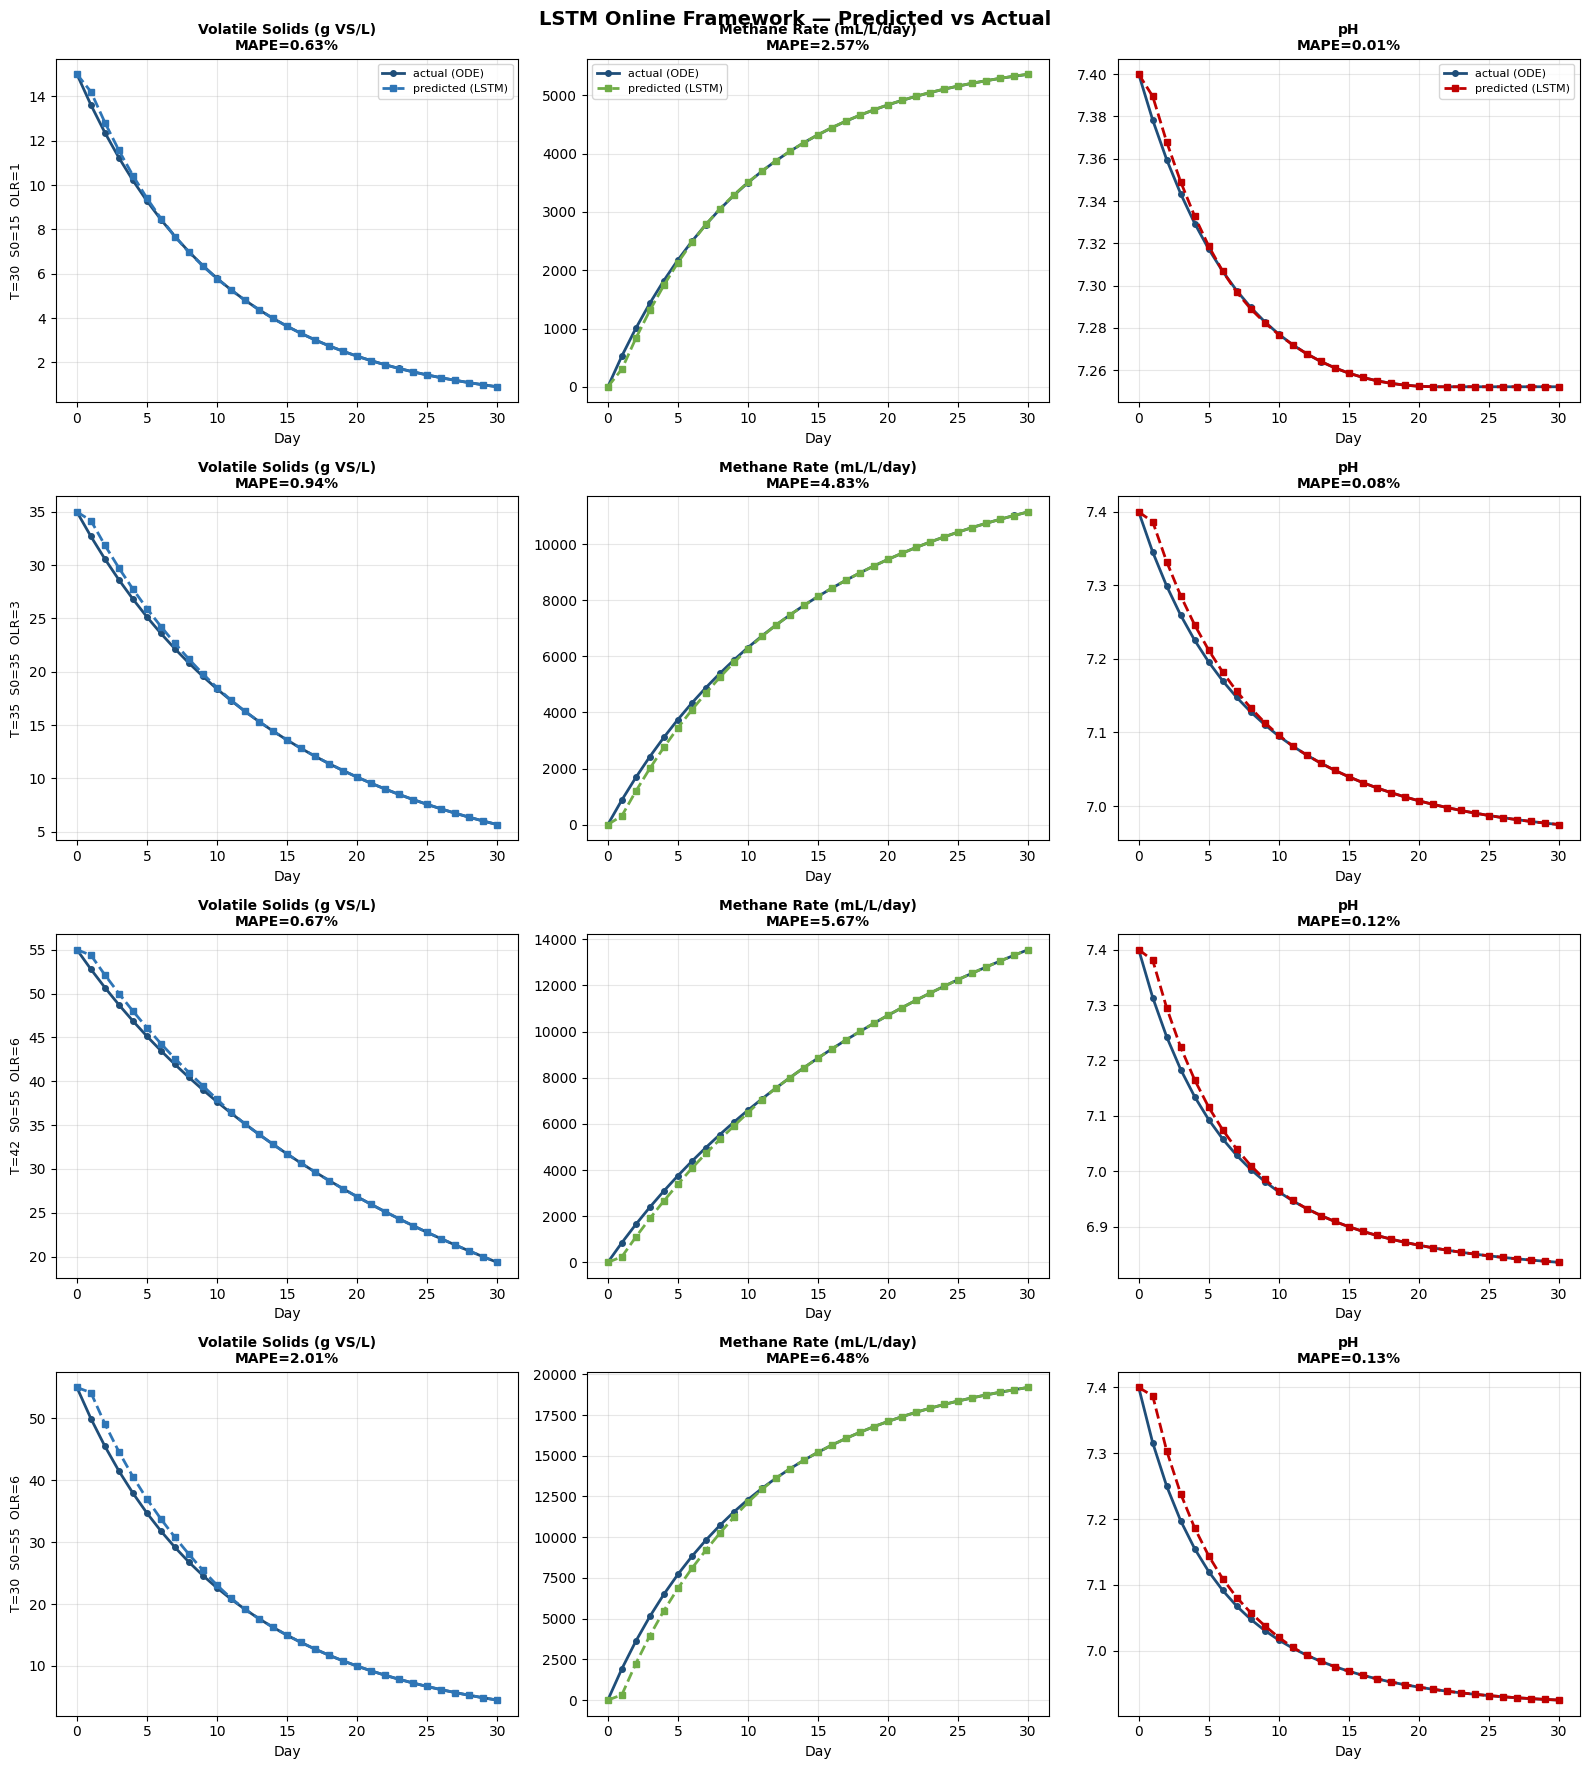

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
var_names   = ['Volatile Solids (g VS/L)', 'Methane Rate (mL/L/day)', 'pH']
colors_pred = ['#2E75B6', '#70AD47', '#C00000']

for ri, res in enumerate(online_results):
    t = np.arange(31)
    for vi, (vname, cp) in enumerate(zip(var_names, colors_pred)):
        ax = axes[ri, vi]
        ax.plot(t, res['actual'][:, vi], 'o-', color='#1F4E79',
                linewidth=2, markersize=4, label='actual (ODE)')
        ax.plot(t, res['predicted'][:, vi], 's--', color=cp,
                linewidth=2, markersize=4, label='predicted (LSTM)')
        mape_val = [res['mape_S'], res['mape_M'], res['mape_pH']][vi]
        ax.set_title(f"{vname}\nMAPE={mape_val:.2f}%", fontsize=10,
                     fontweight='bold')
        ax.set_xlabel('Day')
        ax.grid(True, alpha=0.3)
        if vi == 0:
            ax.set_ylabel(res['label'].split('(')[0].strip(), fontsize=9)
        if ri == 0:
            ax.legend(fontsize=8)

plt.suptitle('LSTM Online Framework — Predicted vs Actual',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Offline Framework

In [8]:
offline_results = []

for run in test_data:
    T   = run['T']
    OLR = run['OLR']
    sol = run['trajectory']

    state          = sol[0].copy()
    history        = [state.copy()]
    predicted_traj = [state.copy()]

    for i in range(30):
        window_start = max(0, len(history) - seq_len)
        window = np.array(history[window_start:])

        if len(window) < seq_len:
            pad    = np.tile(history[0], (seq_len - len(window), 1))
            window = np.vstack([pad, window])

        seq_raw = np.zeros((seq_len, 8))
        seq_raw[:, 0:3] = window
        seq_raw[:, 3]   = T
        seq_raw[:, 4]   = OLR
        seq_std = scaler.transform(seq_raw)[:, 0:5]

        x_t = torch.tensor(seq_std, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            rates_std = model(x_t).numpy()[0]

        full_std = np.zeros(8)
        full_std[0:5] = seq_std[-1]
        full_std[5:8] = rates_std
        full_phys = scaler.inverse_transform(full_std.reshape(1, -1))[0]
        dS, dM, dpH = full_phys[5], full_phys[6], full_phys[7]
        dpH = min(dpH, 0.0)

        S_next  = max(state[0] + dS,  0.0)
        M_next  = max(state[1] + dM,  0.0)
        pH_next = max(state[2] + dpH, pH_eq)

        state = np.array([S_next, M_next, pH_next])
        history.append(state.copy())
        predicted_traj.append(state.copy())

    predicted_traj = np.array(predicted_traj)

    mape_S  = MAPE(sol[1:, 0], predicted_traj[1:, 0])
    mape_M  = MAPE(sol[1:, 1], predicted_traj[1:, 1])
    mape_pH = MAPE(sol[1:, 2], predicted_traj[1:, 2])

    offline_results.append({
        'label': run['label'], 'actual': sol, 'predicted': predicted_traj,
        'mape_S': mape_S, 'mape_M': mape_M, 'mape_pH': mape_pH,
    })

    print(f"{run['label']}")
    print(f"  MAPE S:   {mape_S:.2f}%")
    print(f"  MAPE M:   {mape_M:.2f}%")
    print(f"  MAPE pH:  {mape_pH:.2f}%")
    print()

T=30  S0=15  OLR=1  (low temp, low substrate)
  MAPE S:   26.21%
  MAPE M:   13.72%
  MAPE pH:  0.18%

T=35  S0=35  OLR=3  (optimal conditions)
  MAPE S:   52.65%
  MAPE M:   38.29%
  MAPE pH:  1.69%

T=42  S0=55  OLR=6  (high temp, high substrate)
  MAPE S:   32.13%
  MAPE M:   49.21%
  MAPE pH:  2.48%

T=30  S0=55  OLR=6  (low temp, high substrate)
  MAPE S:   193.36%
  MAPE M:   63.27%
  MAPE pH:  2.85%



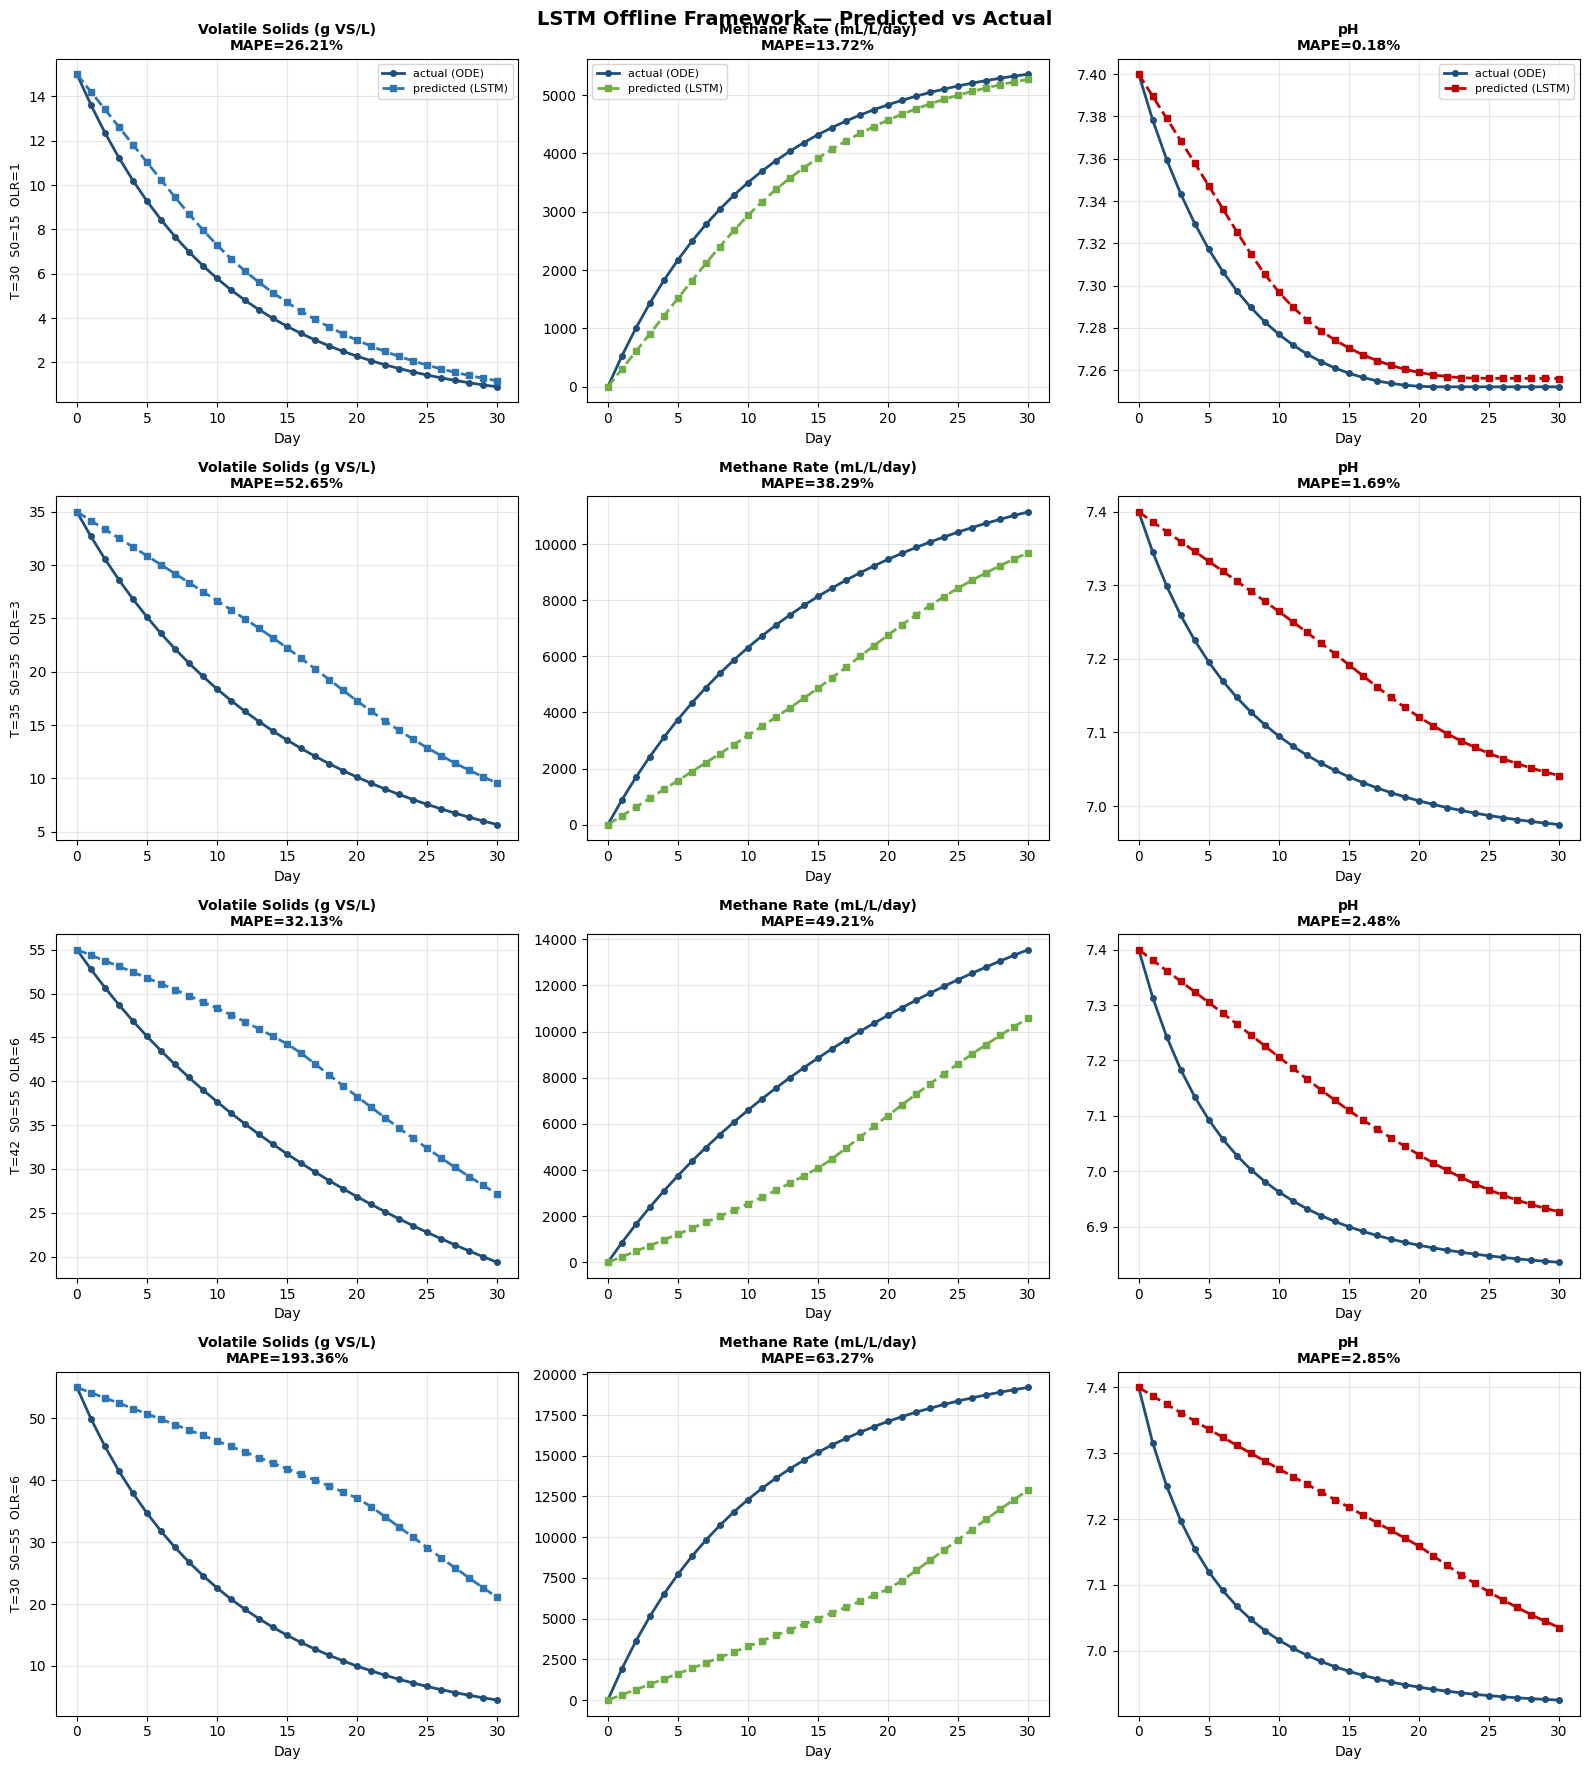

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))

for ri, res in enumerate(offline_results):
    t = np.arange(31)
    for vi, (vname, cp) in enumerate(zip(var_names, colors_pred)):
        ax = axes[ri, vi]
        ax.plot(t, res['actual'][:, vi], 'o-', color='#1F4E79',
                linewidth=2, markersize=4, label='actual (ODE)')
        ax.plot(t, res['predicted'][:, vi], 's--', color=cp,
                linewidth=2, markersize=4, label='predicted (LSTM)')
        mape_val = [res['mape_S'], res['mape_M'], res['mape_pH']][vi]
        ax.set_title(f"{vname}\nMAPE={mape_val:.2f}%", fontsize=10,
                     fontweight='bold')
        ax.set_xlabel('Day')
        ax.grid(True, alpha=0.3)
        if vi == 0:
            ax.set_ylabel(res['label'].split('(')[0].strip(), fontsize=9)
        if ri == 0:
            ax.legend(fontsize=8)

plt.suptitle('LSTM Offline Framework — Predicted vs Actual',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Results Extractor and Full Comparison

In [10]:
ann_online  = {'S': 0.07, 'M': 0.06, 'pH': 0.00}
ann_offline = {'S': 0.45, 'M': 0.29, 'pH': 0.02}
rnn_online  = {'S': 0.56, 'M': 2.76, 'pH': 0.06}
rnn_offline = {'S': 24.02, 'M': 17.19, 'pH': 1.02}

online_mape_S  = [r['mape_S']   for r in online_results]
online_mape_M  = [r['mape_M']   for r in online_results]
online_mape_pH = [r['mape_pH']  for r in online_results]
offline_mape_S  = [r['mape_S']  for r in offline_results]
offline_mape_M  = [r['mape_M']  for r in offline_results]
offline_mape_pH = [r['mape_pH'] for r in offline_results]

print("=" * 60)
print("NOTEBOOK RESULTS SUMMARY")
print("=" * 60)
print()
print("ONLINE MAPE:")
for r in online_results:
    print(f"  {r['label']}")
    print(f"    S:{r['mape_S']:.2f}%  M:{r['mape_M']:.2f}%  pH:{r['mape_pH']:.2f}%")
print(f"  MEAN: S:{np.mean(online_mape_S):.2f}%  "
      f"M:{np.mean(online_mape_M):.2f}%  pH:{np.mean(online_mape_pH):.2f}%")
print()
print("OFFLINE MAPE:")
for r in offline_results:
    print(f"  {r['label']}")
    print(f"    S:{r['mape_S']:.2f}%  M:{r['mape_M']:.2f}%  pH:{r['mape_pH']:.2f}%")
print(f"  MEAN: S:{np.mean(offline_mape_S):.2f}%  "
      f"M:{np.mean(offline_mape_M):.2f}%  pH:{np.mean(offline_mape_pH):.2f}%")
print()
print("FULL MODEL COMPARISON — OFFLINE MEAN MAPE:")
print(f"  {'Model':<20} {'S':>8} {'M':>8} {'pH':>8}")
print(f"  {'ANN':<20} {ann_offline['S']:>8.2f}%  {ann_offline['M']:>6.2f}%  {ann_offline['pH']:>6.2f}%")
print(f"  {'RNN':<20} {rnn_offline['S']:>8.2f}%  {rnn_offline['M']:>6.2f}%  {rnn_offline['pH']:>6.2f}%")
print(f"  {'LSTM':<20} {np.mean(offline_mape_S):>8.2f}%  "
      f"{np.mean(offline_mape_M):>6.2f}%  {np.mean(offline_mape_pH):>6.2f}%")
print()

all_offline = offline_mape_S + offline_mape_M + offline_mape_pH
mean_all = np.mean(all_offline)
if mean_all < 2:
    verdict = "EXCELLENT"
elif mean_all < 5:
    verdict = "GOOD"
elif mean_all < 10:
    verdict = "ACCEPTABLE"
else:
    verdict = "NEEDS IMPROVEMENT"

print(f"OVERALL LSTM VERDICT: {verdict}")
print("=" * 60)
print()

NOTEBOOK RESULTS SUMMARY

ONLINE MAPE:
  T=30  S0=15  OLR=1  (low temp, low substrate)
    S:0.63%  M:2.57%  pH:0.01%
  T=35  S0=35  OLR=3  (optimal conditions)
    S:0.94%  M:4.83%  pH:0.08%
  T=42  S0=55  OLR=6  (high temp, high substrate)
    S:0.67%  M:5.67%  pH:0.12%
  T=30  S0=55  OLR=6  (low temp, high substrate)
    S:2.01%  M:6.48%  pH:0.13%
  MEAN: S:1.06%  M:4.89%  pH:0.08%

OFFLINE MAPE:
  T=30  S0=15  OLR=1  (low temp, low substrate)
    S:26.21%  M:13.72%  pH:0.18%
  T=35  S0=35  OLR=3  (optimal conditions)
    S:52.65%  M:38.29%  pH:1.69%
  T=42  S0=55  OLR=6  (high temp, high substrate)
    S:32.13%  M:49.21%  pH:2.48%
  T=30  S0=55  OLR=6  (low temp, high substrate)
    S:193.36%  M:63.27%  pH:2.85%
  MEAN: S:76.09%  M:41.12%  pH:1.80%

FULL MODEL COMPARISON — OFFLINE MEAN MAPE:
  Model                       S        M       pH
  ANN                      0.45%    0.29%    0.02%
  RNN                     24.02%   17.19%    1.02%
  LSTM                    76.09%   41.12%

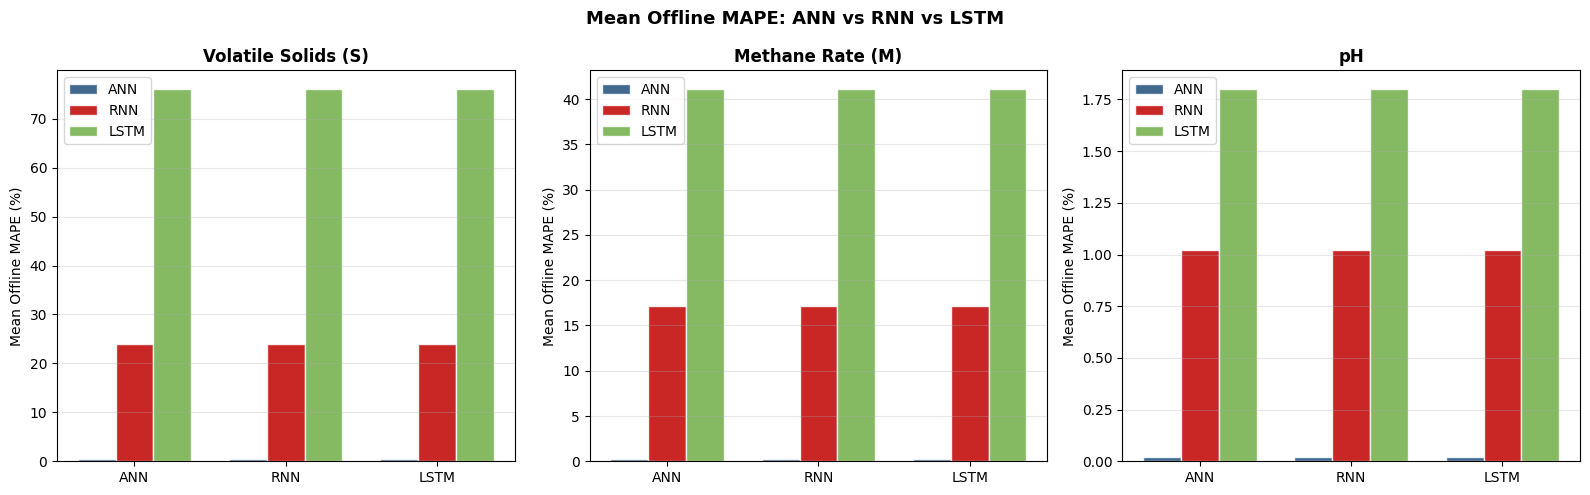

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
var_labels = ['Volatile Solids (S)', 'Methane Rate (M)', 'pH']
run_labels = [r['label'].split('(')[1].rstrip(')') for r in online_results]

ann_off_vals  = [ann_offline['S'],         ann_offline['M'],         ann_offline['pH']]
rnn_off_vals  = [rnn_offline['S'],         rnn_offline['M'],         rnn_offline['pH']]
lstm_off_vals = [np.mean(offline_mape_S),  np.mean(offline_mape_M),  np.mean(offline_mape_pH)]

x     = np.arange(3)
width = 0.25

for vi, (ax, var_label) in enumerate(zip(axes, var_labels)):
    run_s = [offline_results[ri][['mape_S','mape_M','mape_pH'][vi]] for ri in range(4)]
    b1 = ax.bar(x - width, [ann_off_vals[vi]]*3, width,
                label='ANN', color='#1F4E79', alpha=0.85, edgecolor='white')
    b2 = ax.bar(x,          [rnn_off_vals[vi]]*3, width,
                label='RNN', color='#C00000', alpha=0.85, edgecolor='white')
    b3 = ax.bar(x + width,  [lstm_off_vals[vi]]*3, width,
                label='LSTM', color='#70AD47', alpha=0.85, edgecolor='white')

    ax.set_ylabel('Mean Offline MAPE (%)')
    ax.set_title(f'{var_label}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['ANN', 'RNN', 'LSTM'])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Mean Offline MAPE: ANN vs RNN vs LSTM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()